In [3]:
import pandas as pd
import numpy as np
dataset = pd.read_csv("C:\\Users\\krise\\OneDrive\\Attachments\\Desktop\\data.me\\Projects\\Kids’ Screentime Visualization\\Indian_Kids_Screen_Time.csv")
dataset.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [4]:
dataset.tail()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban
9711,15,Female,6.12,TV,True,0.33,Anxiety,Urban


In [5]:
dataset.shape

(9712, 8)

In [6]:
dataset.columns

Index(['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device',
       'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio',
       'Health_Impacts', 'Urban_or_Rural'],
      dtype='object')

In [7]:
dataset.columns = dataset.columns.str.strip()

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [9]:
dataset.describe()

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [10]:
dataset.isnull().sum()

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64

In [11]:
dataset['Health_Impacts'] = dataset['Health_Impacts'].fillna("No Health Impact")

In [12]:
dataset.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,No Health Impact,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [13]:
dataset.isnull().sum()

Age                                  0
Gender                               0
Avg_Daily_Screen_Time_hr             0
Primary_Device                       0
Exceeded_Recommended_Limit           0
Educational_to_Recreational_Ratio    0
Health_Impacts                       0
Urban_or_Rural                       0
dtype: int64

In [14]:
dataset.duplicated().sum()

44

In [15]:
dataset = dataset.drop_duplicates()

In [16]:
dataset.duplicated().sum()

0

In [17]:
dataset["Age"].min()

8

In [18]:
dataset["Age"].max()

18

In [19]:
dataset["Avg_Daily_Screen_Time_hr"].min()

0.0

In [20]:
dataset["Avg_Daily_Screen_Time_hr"].max()

13.89

In [21]:
(dataset["Avg_Daily_Screen_Time_hr"] < 0).sum()

0

In [22]:
dataset["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [23]:
dataset["Primary_Device"].unique()

array(['Smartphone', 'Laptop', 'TV', 'Tablet'], dtype=object)

In [24]:
dataset["Urban_or_Rural"].unique()

array(['Urban', 'Rural'], dtype=object)

In [25]:
dataset["Health_Impacts"].unique()

array(['Poor Sleep, Eye Strain', 'Poor Sleep', 'No Health Impact',
       'Poor Sleep, Anxiety', 'Poor Sleep, Obesity Risk', 'Eye Strain',
       'Obesity Risk', 'Anxiety', 'Poor Sleep, Anxiety, Obesity Risk',
       'Eye Strain, Obesity Risk', 'Eye Strain, Anxiety, Obesity Risk',
       'Anxiety, Obesity Risk', 'Poor Sleep, Eye Strain, Obesity Risk',
       'Poor Sleep, Eye Strain, Anxiety',
       'Poor Sleep, Eye Strain, Anxiety, Obesity Risk',
       'Eye Strain, Anxiety'], dtype=object)

In [26]:
text_cols = ["Gender", "Primary_Device", "Urban_or_Rural", "Health_Impacts"]

for col in text_cols:
    dataset.loc[:, col] = dataset[col].str.strip().str.title()

In [27]:
for col in text_cols:
    print(col, dataset[col].unique())

Gender ['Male' 'Female']
Primary_Device ['Smartphone' 'Laptop' 'Tv' 'Tablet']
Urban_or_Rural ['Urban' 'Rural']
Health_Impacts ['Poor Sleep, Eye Strain' 'Poor Sleep' 'No Health Impact'
 'Poor Sleep, Anxiety' 'Poor Sleep, Obesity Risk' 'Eye Strain'
 'Obesity Risk' 'Anxiety' 'Poor Sleep, Anxiety, Obesity Risk'
 'Eye Strain, Obesity Risk' 'Eye Strain, Anxiety, Obesity Risk'
 'Anxiety, Obesity Risk' 'Poor Sleep, Eye Strain, Obesity Risk'
 'Poor Sleep, Eye Strain, Anxiety'
 'Poor Sleep, Eye Strain, Anxiety, Obesity Risk' 'Eye Strain, Anxiety']


In [28]:
text_cols = ["Gender", "Primary_Device", "Urban_or_Rural", "Health_Impacts"]

for col in text_cols:
    dataset.loc[:, col] = dataset[col].str.strip().str.title()

In [29]:
for col in text_cols:
    print(col, dataset[col].unique())

Gender ['Male' 'Female']
Primary_Device ['Smartphone' 'Laptop' 'Tv' 'Tablet']
Urban_or_Rural ['Urban' 'Rural']
Health_Impacts ['Poor Sleep, Eye Strain' 'Poor Sleep' 'No Health Impact'
 'Poor Sleep, Anxiety' 'Poor Sleep, Obesity Risk' 'Eye Strain'
 'Obesity Risk' 'Anxiety' 'Poor Sleep, Anxiety, Obesity Risk'
 'Eye Strain, Obesity Risk' 'Eye Strain, Anxiety, Obesity Risk'
 'Anxiety, Obesity Risk' 'Poor Sleep, Eye Strain, Obesity Risk'
 'Poor Sleep, Eye Strain, Anxiety'
 'Poor Sleep, Eye Strain, Anxiety, Obesity Risk' 'Eye Strain, Anxiety']


In [43]:
dataset['Age_Group'] = pd.cut(
    dataset['Age'],
    bins=[5,8,12,16],
    labels=["Young Kids","Pre-Teens","Teenagers"]
)

In [41]:
device_share = dataset["Primary_Device"].value_counts(normalize=True) * 100
device_share

Primary_Device
Smartphone    46.959040
Tv            25.630947
Laptop        14.801407
Tablet        12.608606
Name: proportion, dtype: float64

In [32]:
dataset.loc[:, "Activity_Type"] = np.where(
    dataset["Educational_to_Recreational_Ratio"].fillna(0) >= 1,
    "Education Dominant",
    "Recreation Dominant"
)

In [33]:
dataset["Activity_Type"].value_counts()

Activity_Type
Recreation Dominant    9668
Name: count, dtype: int64

In [34]:
dataset.to_csv("kids_screentime_cleaned.csv", index=False)

# Distribution of Daily Screen Time

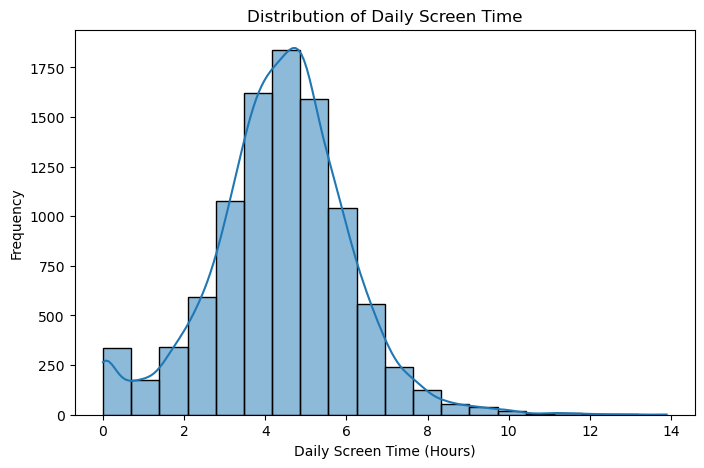

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(dataset["Avg_Daily_Screen_Time_hr"], bins=20, kde=True)
plt.title("Distribution of Daily Screen Time")
plt.xlabel("Daily Screen Time (Hours)")
plt.ylabel("Frequency")
plt.show()

# Age Distribution

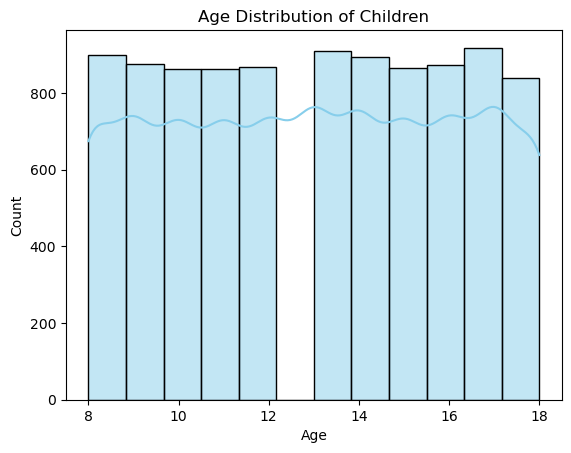

In [49]:
sns.histplot(dataset["Age"], bins=12, kde=True, color="skyblue")
plt.title("Age Distribution of Children")
plt.show()

# Gender Distribution

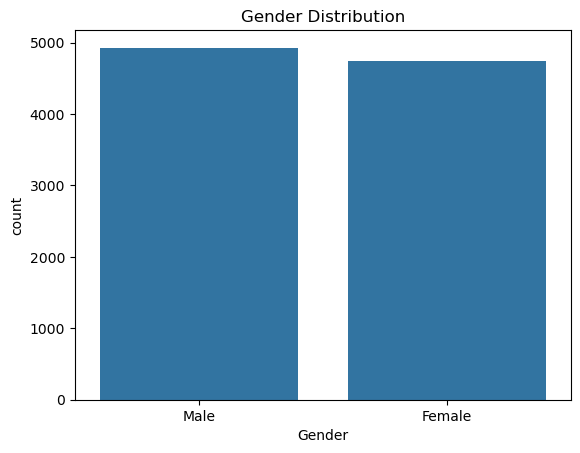

In [37]:
sns.countplot(x='Gender', data=dataset)
plt.title("Gender Distribution")
plt.show()

# Distribution of Primary Device

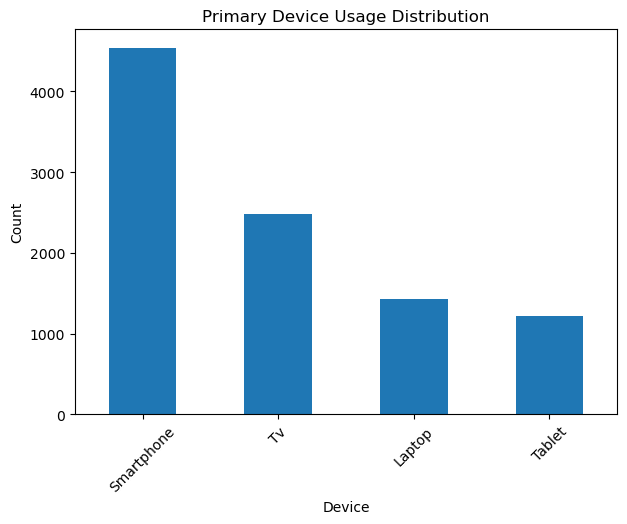

In [39]:
plt.figure(figsize=(7,5))
dataset["Primary_Device"].value_counts().plot(kind="bar")
plt.title("Primary Device Usage Distribution")
plt.xlabel("Device")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Screen Time by Gender

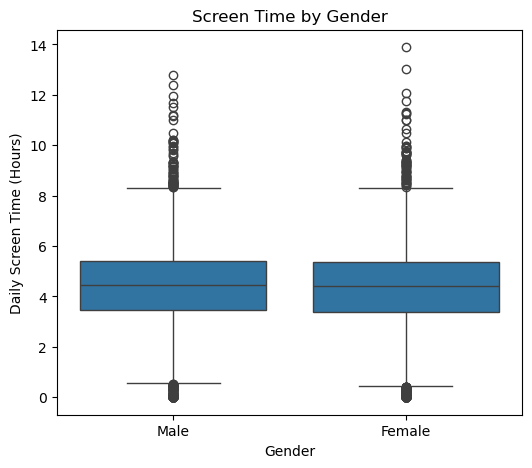

In [46]:
plt.figure(figsize=(6,5))
sns.boxplot(x="Gender", y="Avg_Daily_Screen_Time_hr", data=dataset)
plt.title("Screen Time by Gender")
plt.xlabel("Gender")
plt.ylabel("Daily Screen Time (Hours)")
plt.show()

# Screen Time by Age

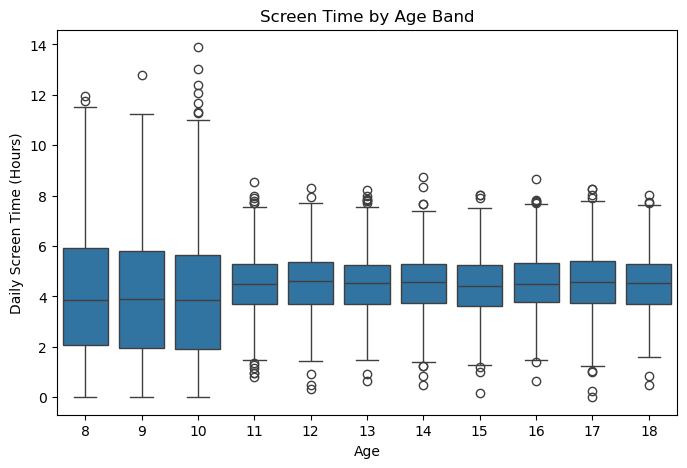

In [69]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Age", y="Avg_Daily_Screen_Time_hr", data=dataset)
plt.title("Screen Time by Age Band")
plt.xlabel("Age")
plt.ylabel("Daily Screen Time (Hours)")
plt.show()

# Screen Time by Location Type

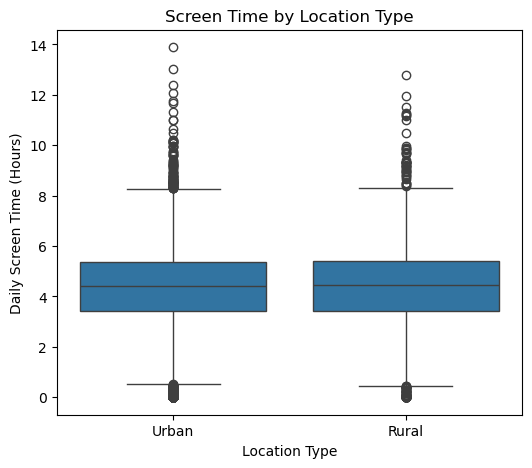

In [47]:
plt.figure(figsize=(6,5))
sns.boxplot(x="Urban_or_Rural", y="Avg_Daily_Screen_Time_hr", data=dataset)
plt.title("Screen Time by Location Type")
plt.xlabel("Location Type")
plt.ylabel("Daily Screen Time (Hours)")
plt.show()

# Average Screen Time by Age 

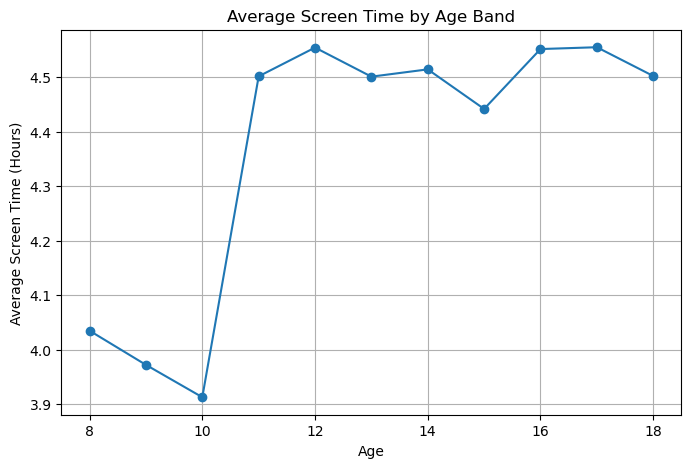

In [71]:
avg_age = dataset.groupby("Age")["Avg_Daily_Screen_Time_hr"].mean()
plt.figure(figsize=(8,5))
avg_age.plot(marker="o")
plt.title("Average Screen Time by Age Band")
plt.xlabel("Age")
plt.ylabel("Average Screen Time (Hours)")
plt.grid(True)
plt.show()

# Device Usage by Gender

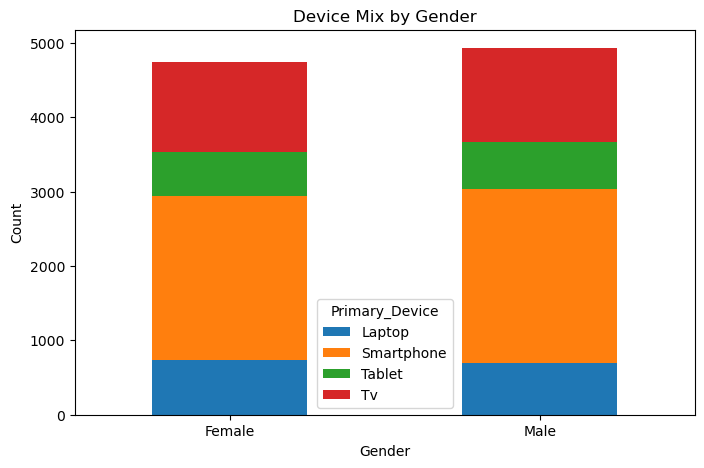

In [72]:
device_gender = pd.crosstab(dataset["Gender"], dataset["Primary_Device"])
device_gender.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Device Mix by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Device Usage by Age

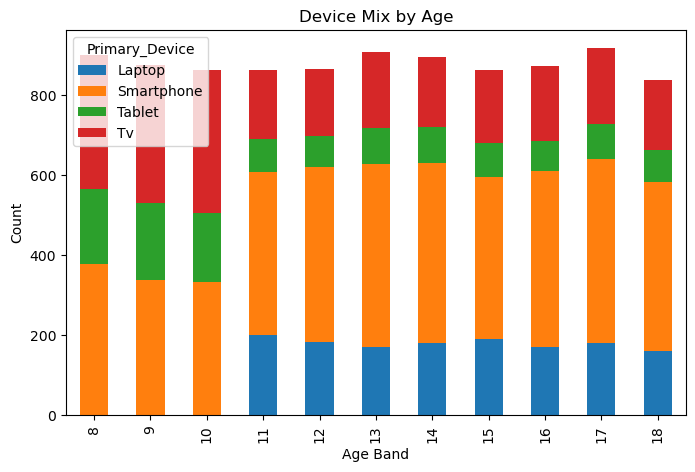

In [73]:
device_age = pd.crosstab(dataset["Age"], dataset["Primary_Device"])
device_age.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Device Mix by Age")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.show()

# Activity Type by Gender

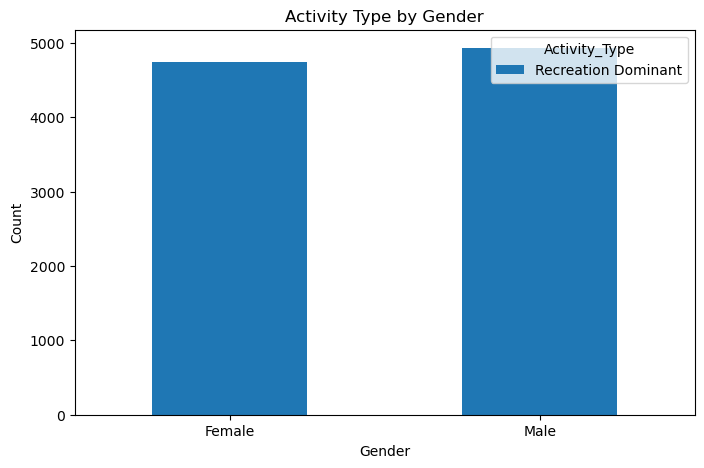

In [75]:
activity_gender = pd.crosstab(dataset["Gender"], dataset["Activity_Type"])
activity_gender.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Activity Type by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Activity Type by Age 

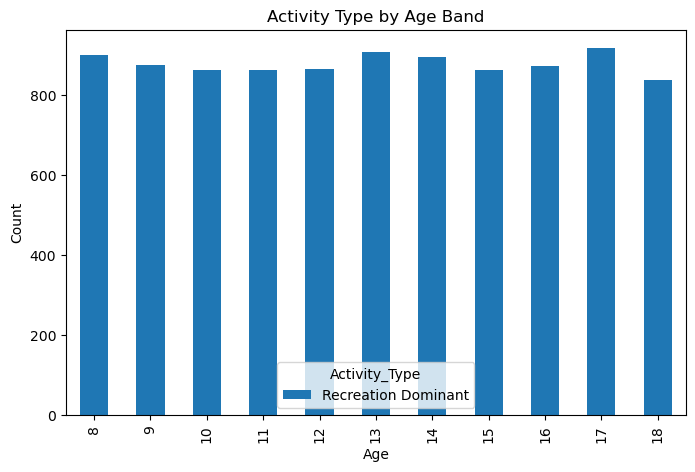

In [76]:
activity_age = pd.crosstab(dataset["Age"], dataset["Activity_Type"])
activity_age.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Activity Type by Age Band")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Activity Type by Location

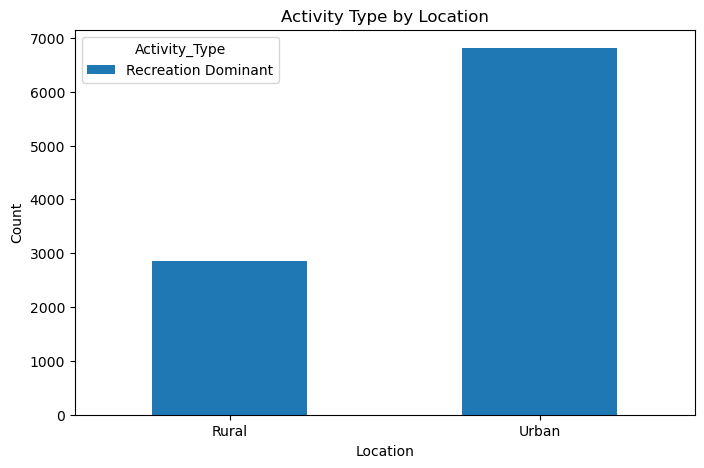

In [60]:
activity_location = pd.crosstab(dataset["Urban_or_Rural"], dataset["Activity_Type"])
activity_location.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Activity Type by Location")
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Peak Cohort Identification

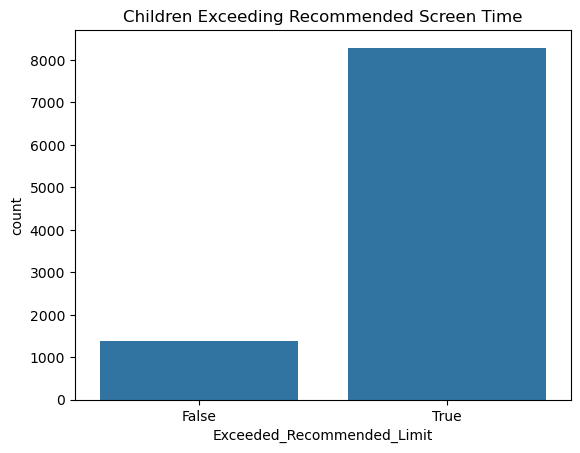

In [51]:
sns.countplot(x="Exceeded_Recommended_Limit", data=dataset)
plt.title("Children Exceeding Recommended Screen Time")
plt.show()

# Screen Time vs Recommended Limit

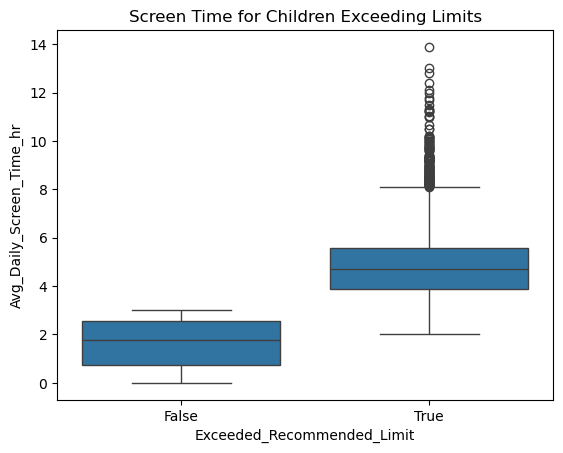

In [52]:
sns.boxplot(x="Exceeded_Recommended_Limit",
            y="Avg_Daily_Screen_Time_hr",
            data=dataset)
plt.title("Screen Time for Children Exceeding Limits")

plt.show()

# Device vs Limit Exceeded

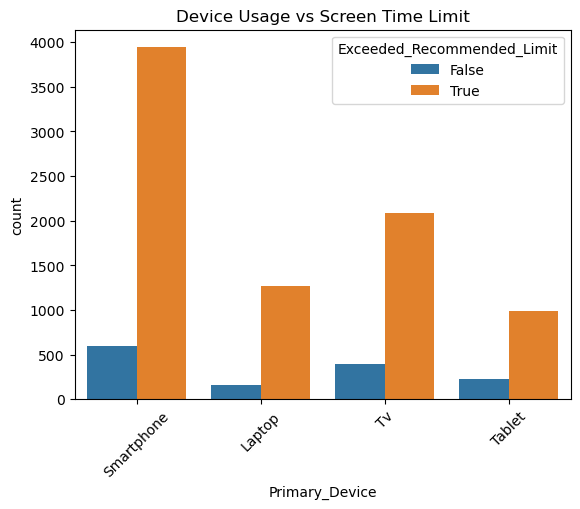

In [53]:
sns.countplot(x="Primary_Device",
              hue="Exceeded_Recommended_Limit",
              data=dataset)
plt.xticks(rotation=45)
plt.title("Device Usage vs Screen Time Limit")
plt.show()

# Education vs Recreation Ratio Distribution

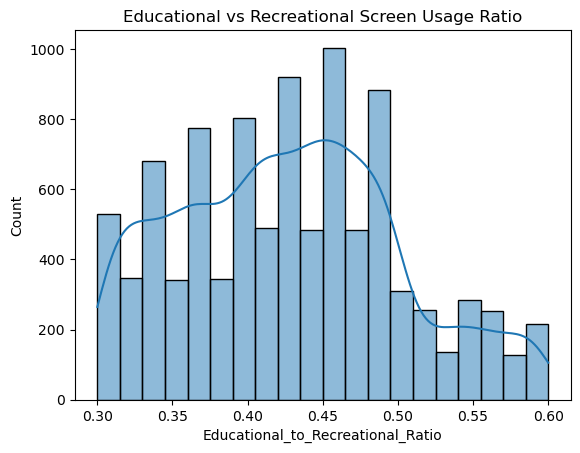

In [54]:
sns.histplot(dataset["Educational_to_Recreational_Ratio"],
             bins=20,
             kde=True)
plt.title("Educational vs Recreational Screen Usage Ratio")
plt.show()

# Ratio vs Screen Time

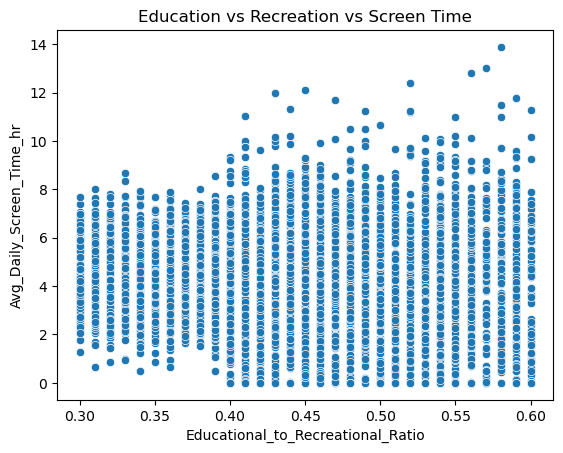

In [55]:
sns.scatterplot(x="Educational_to_Recreational_Ratio",
                y="Avg_Daily_Screen_Time_hr",
                data=dataset)
plt.title("Education vs Recreation vs Screen Time")
plt.show()

# Health Impact Distribution

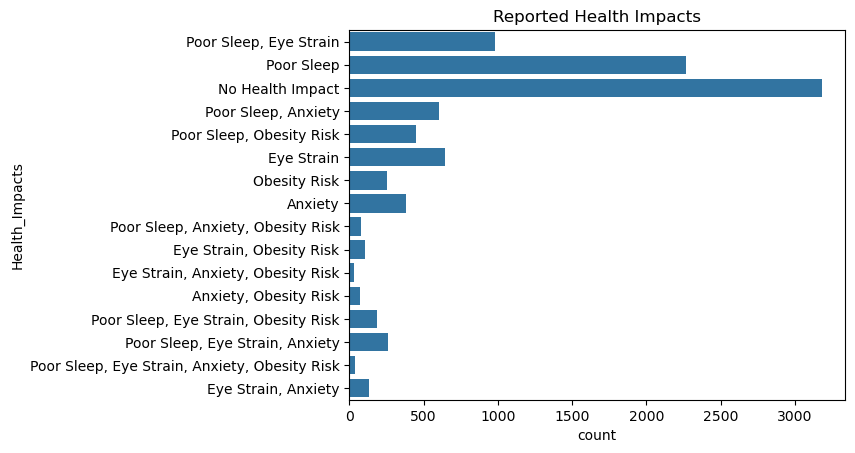

In [56]:
sns.countplot(y="Health_Impacts", data=dataset)
plt.title("Reported Health Impacts")
plt.show()

# Screen Time vs Health Impact

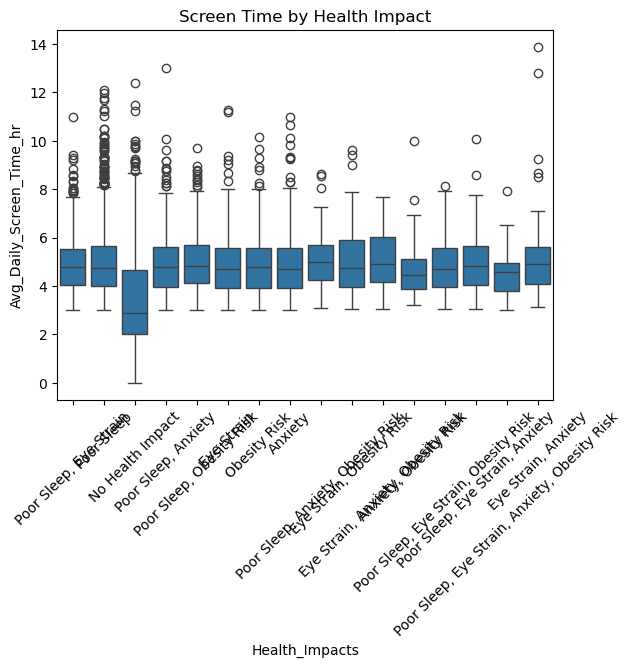

In [57]:
sns.boxplot(x="Health_Impacts",
            y="Avg_Daily_Screen_Time_hr",
            data=dataset)
plt.xticks(rotation=45)
plt.title("Screen Time by Health Impact")
plt.show()

# Device vs Health Impact

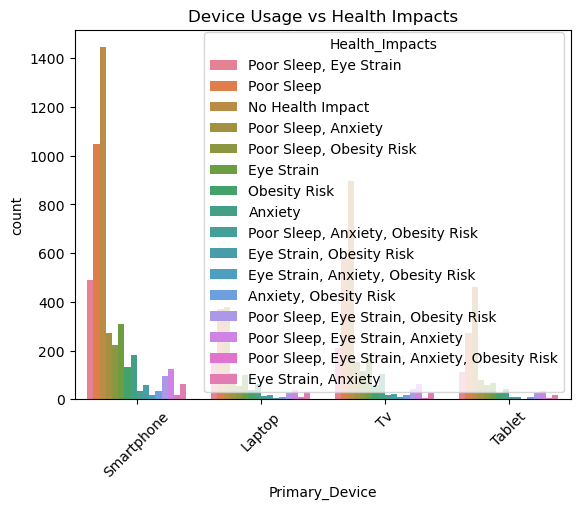

In [58]:
sns.countplot(x="Primary_Device",
              hue="Health_Impacts",
              data=dataset)
plt.xticks(rotation=45)
plt.title("Device Usage vs Health Impacts")
plt.show()

# Device Preference by Location

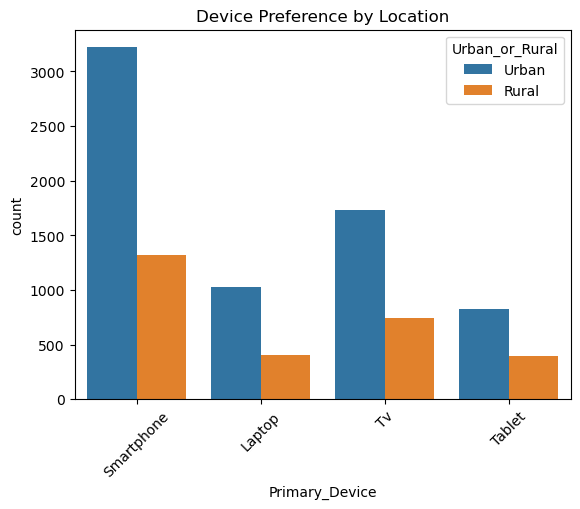

In [59]:
sns.countplot(x="Primary_Device",
              hue="Urban_or_Rural",
              data=dataset)
plt.xticks(rotation=45)
plt.title("Device Preference by Location")
plt.show()

In [50]:
peak = dataset.groupby(
    ["Age", "Gender", "Urban_or_Rural"]
)["Avg_Daily_Screen_Time_hr"].mean().reset_index()

peak.sort_values(by="Avg_Daily_Screen_Time_hr", ascending=False).head(5)

,Age,Gender,Urban_or_Rural,Avg_Daily_Screen_Time_hr
32,16,Female,Rural,4.768718
36,17,Female,Rural,4.690342
16,12,Female,Rural,4.599487
18,12,Male,Rural,4.594400
37,17,Female,Urban,4.593761


In [ ]:
# Children Exceeding Screen Time Limit

# Age × Device Type (Average Screen Time)

In [79]:
cohort_age_device = dataset.groupby(
    ["Age", "Primary_Device"]
)["Avg_Daily_Screen_Time_hr"].mean().reset_index()
cohort_age_device.sort_values(
    by="Avg_Daily_Screen_Time_hr",
    ascending=False
).head(10)

,Age,Primary_Device,Avg_Daily_Screen_Time_hr
32,16,Tv,4.655989
20,13,Tv,4.652760
29,16,Laptop,4.650296
35,17,Tablet,4.623488
22,14,Smartphone,4.619290
14,12,Smartphone,4.601027
33,17,Laptop,4.578278
16,12,Tv,4.565325
34,17,Smartphone,4.561061
11,11,Tablet,4.555952


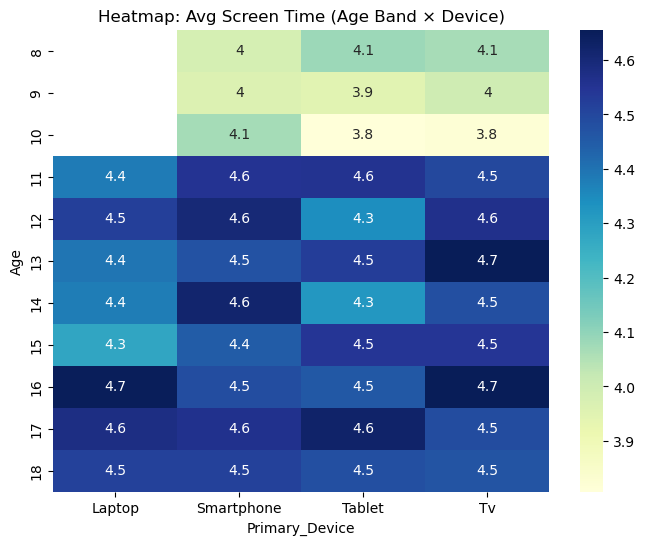

In [80]:

pivot_age_device = dataset.pivot_table(
    values="Avg_Daily_Screen_Time_hr",
    index="Age",
    columns="Primary_Device",
    aggfunc="mean"
)
plt.figure(figsize=(8,6))
sns.heatmap(pivot_age_device, annot=True, cmap="YlGnBu")
plt.title("Heatmap: Avg Screen Time (Age Band × Device)")
plt.show()

# Age × Gender (Average Screen Time)

In [81]:
cohort_age_gender = dataset.groupby(
    ["Age", "Gender"]
)["Avg_Daily_Screen_Time_hr"].mean().reset_index()
cohort_age_gender.sort_values(
    by="Avg_Daily_Screen_Time_hr",
    ascending=False
)

,Age,Gender,Avg_Daily_Screen_Time_hr
18,17,Female,4.619212
9,12,Male,4.570092
13,14,Male,4.567825
16,16,Female,4.559257
17,16,Male,4.545085
8,12,Female,4.538422
20,18,Female,4.531253
6,11,Female,4.513679
11,13,Male,4.506593
10,13,Female,4.495341


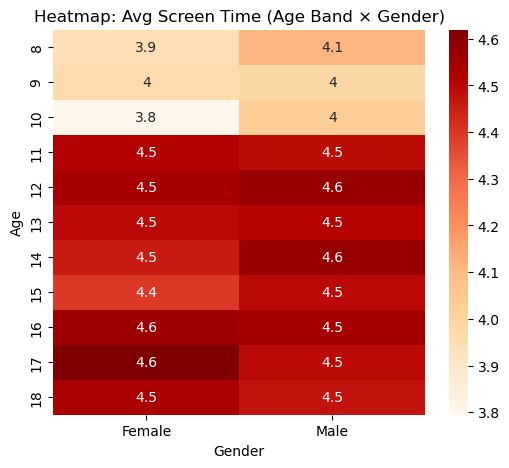

In [82]:
pivot_age_gender = dataset.pivot_table(
    values="Avg_Daily_Screen_Time_hr",
    index="Age",
    columns="Gender",
    aggfunc="mean"
)
plt.figure(figsize=(6,5))
sns.heatmap(pivot_age_gender, annot=True, cmap="OrRd")
plt.title("Heatmap: Avg Screen Time (Age Band × Gender)")
plt.show()

# Age  × Location (Urban/Rural)

In [83]:
cohort_age_location = dataset.groupby(
    ["Age", "Urban_or_Rural"]
)["Avg_Daily_Screen_Time_hr"].mean().reset_index()

cohort_age_location.sort_values(
    by="Avg_Daily_Screen_Time_hr",
    ascending=False
)

,Age,Urban_or_Rural,Avg_Daily_Screen_Time_hr
16,16,Rural,4.618271
8,12,Rural,4.596860
18,17,Rural,4.560118
19,17,Urban,4.553017
9,12,Urban,4.537888
17,16,Urban,4.522484
13,14,Urban,4.515769
6,11,Rural,4.512355
12,14,Rural,4.511070
21,18,Urban,4.510354


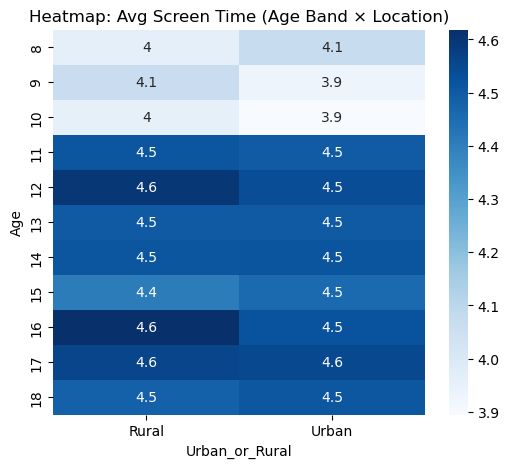

In [84]:
pivot_age_location = dataset.pivot_table(
    values="Avg_Daily_Screen_Time_hr",
    index="Age",
    columns="Urban_or_Rural",
    aggfunc="mean"
)

plt.figure(figsize=(6,5))
sns.heatmap(pivot_age_location, annot=True, cmap="Blues")
plt.title("Heatmap: Avg Screen Time (Age Band × Location)")
plt.show()

# Stacked Bar: Age Band × Device

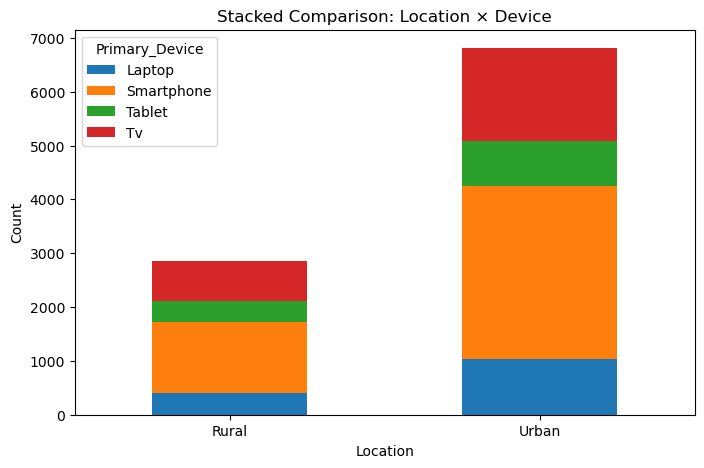

In [85]:
device_location = pd.crosstab(dataset["Urban_or_Rural"], dataset["Primary_Device"])
device_location.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Stacked Comparison: Location × Device")
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Stacked Bar: Location × Device

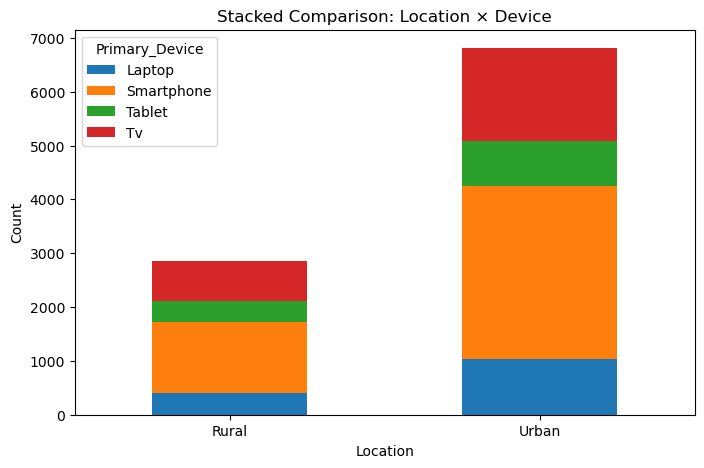

In [86]:
device_location = pd.crosstab(dataset["Urban_or_Rural"], dataset["Primary_Device"])
device_location.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Stacked Comparison: Location × Device")
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Screen Time vs Education Ratio (Regression)

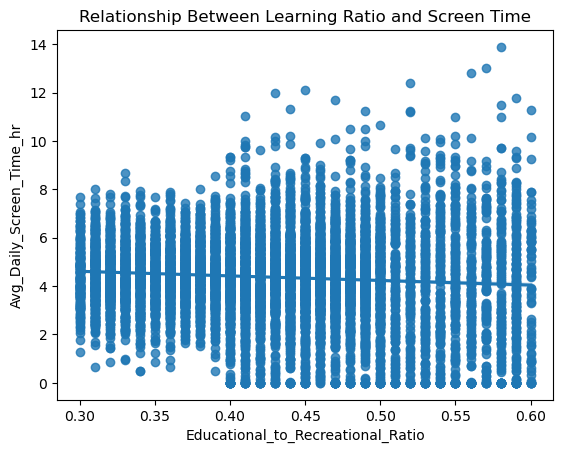

In [61]:
sns.regplot(x="Educational_to_Recreational_Ratio",
            y="Avg_Daily_Screen_Time_hr",
            data=dataset)
plt.title("Relationship Between Learning Ratio and Screen Time")
plt.show()

# Violin Plot Screen Time by Gender

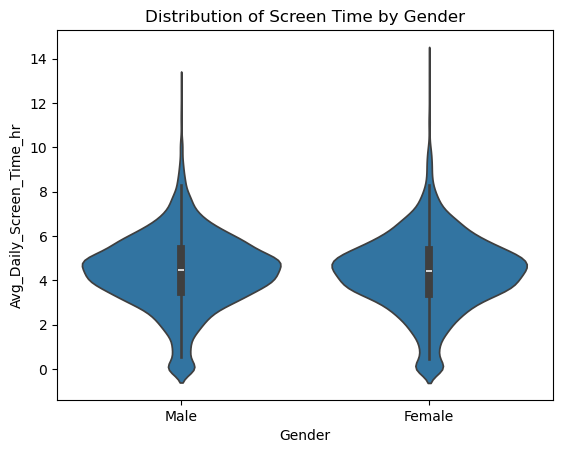

In [62]:
sns.violinplot(x="Gender",
               y="Avg_Daily_Screen_Time_hr",
               data=dataset)
plt.title("Distribution of Screen Time by Gender")
plt.show()

# Heatmap (Device vs Location)

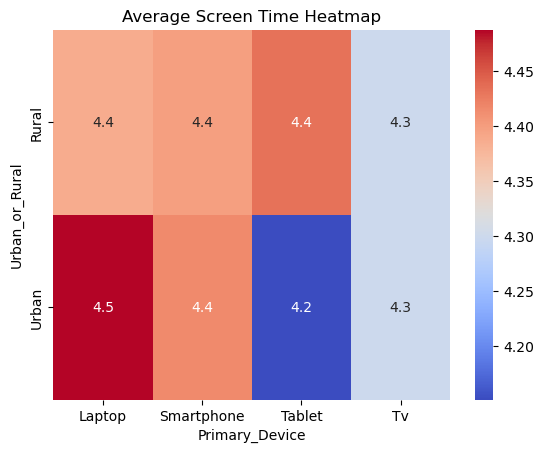

In [63]:
pivot = dataset.pivot_table(
    values="Avg_Daily_Screen_Time_hr",
    index="Urban_or_Rural",
    columns="Primary_Device",
    aggfunc="mean"
)
sns.heatmap(pivot, annot=True, cmap="coolwarm")
plt.title("Average Screen Time Heatmap")
plt.show()

# Correlation Heatmap

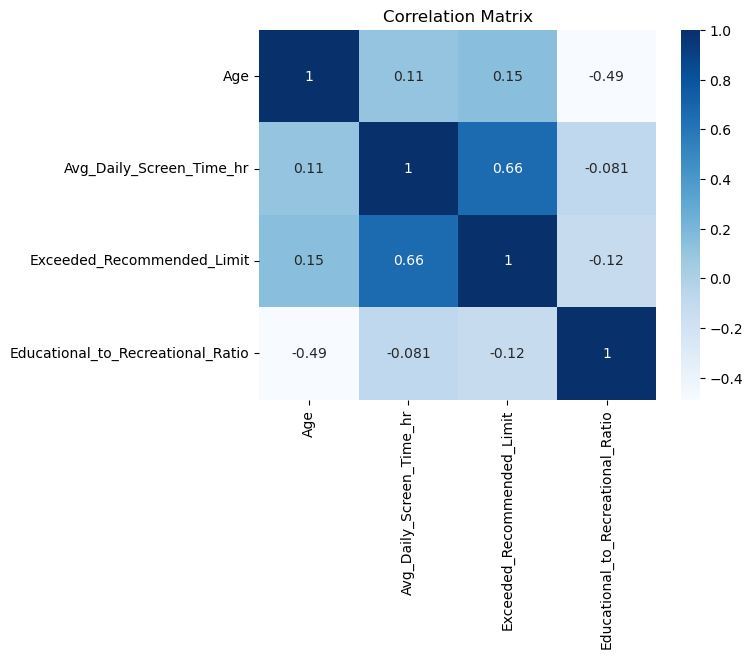

In [64]:
sns.heatmap(dataset.corr(numeric_only=True),
            annot=True,
            cmap="Blues")
plt.title("Correlation Matrix")
plt.show()